## Function Approximation Using Least Squares and Neural Networks

This notebook follows the coursework workflow:    
1. Load and explore the dataset  
2. Prepare training and validation data  
3. Fit a 4th-order polynomial least-squares baseline  
4. Train a feedforward neural network for regression  
5. Evaluate both models on the validation set  
6. Compare optimisation behaviour and generalisation

In [84]:
%pip install numpy pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


## Step 1: Load and explore the dataset

=== Step 1: Dataset overview ===
Training set shape: (400, 2)
Validation set shape: (100, 2)

Training set head:
          x          y
0  1.095824   1.635425
1 -0.244486  -0.338836
2  1.434392   3.926012
3  0.789472  -0.027757
4 -1.623291  11.301925

Validation set head:
          x          y
0 -0.792290   0.380422
1  1.673768   6.860788
2  1.125176   1.614931
3 -1.557646   9.929234
4  1.988139  14.135489

Training summary statistics:
                x           y
count  400.000000  400.000000
mean    -0.013815    3.786131
std      1.140097    5.321142
min     -1.970551   -0.880020
25%     -1.040343    0.006840
50%     -0.034280    1.264769
75%      1.032783    6.678148
max      1.969502   23.986848

Validation summary statistics:
                x           y
count  100.000000  100.000000
mean    -0.031115    4.368830
std      1.180395    6.003807
min     -1.978281   -0.609834
25%     -1.145332    0.180854
50%      0.123767    1.466492
75%      0.864335    6.899558
max      1.996419

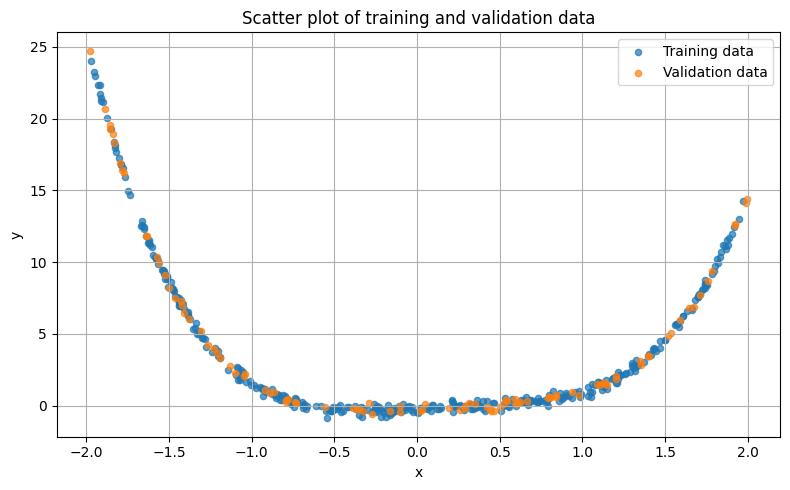

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv('train.csv')  #loads train dataset
val_df = pd.read_csv('val.csv') #loads validation dataset

#.to_numpy(dtype=float): converts the table into NumPy arrays for matrix operations.
#Why use [['x']] instead of ['x']
#Because:['x'] gives a 1D Series;[['x']] gives a 2D DataFrame
#Neural network code and matrix multiplication are easier and safer with shape (n,1).

x_train = train_df[['x']].to_numpy(dtype=float) #extracts the input variable x while keeping a 2D shape.
y_train = train_df[['y']].to_numpy(dtype=float) #extracts the target y
x_val = val_df[['x']].to_numpy(dtype=float)
y_val = val_df[['y']].to_numpy(dtype=float)

print('=== Step 1: Dataset overview ===')
print('Training set shape:', train_df.shape)
print('Validation set shape:', val_df.shape)
print('\nTraining set head:')
print(train_df.head())
print('\nValidation set head:')
print(val_df.head())
print('\nTraining summary statistics:')
print(train_df.describe())
print('\nValidation summary statistics:')
print(val_df.describe())

plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, s=20, alpha=0.7, label='Training data')
plt.scatter(x_val, y_val, s=20, alpha=0.7, label='Validation data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Scatter plot of training and validation data')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

•	The scatter plot shows a clear nonlinear relationship between x and y, so a simple linear model would be inappropriate.  
•	Both the training and validation points follow a very similar smooth U-shaped trend, suggesting they come from the same underlying distribution.  
•	The points are close to the main curve but not exactly on it, which indicates the data contains noise while still preserving a strong overall pattern.  
•	The shape appears smooth and moderately asymmetric, which suggests that a fourth-order polynomial is a reasonable baseline for approximating the function.  
•	Since the validation data overlaps well with the training data, the validation set should provide a fair way to assess generalisation performance and compare the polynomial model with the neural network.

## Step 2: Prepare training and validation data

在这一部分，我们只对神经网络模型使用标准化（standardisation），而不对前面的 least squares / polynomial regression 做标准化处理。
标准化的目标，是把数据转换到一个更适合神经网络训练的尺度上。
具体来说，就是把输入变量 x 和目标变量 y 都调整为：
	•	均值接近 0
	•	标准差接近 1

这样做可以让神经网络在训练时更稳定，也更容易收敛。

这里采用的方法是：
	1.	先只用训练集（training set）计算均值和标准差
	2.	再用这些训练集得到的参数，去标准化训练集和验证集
	3.	神经网络在标准化后的数据上训练和验证



In [86]:
x_mean = x_train.mean(axis=0) # computes the mean of training inputs.
x_std = x_train.std(axis=0) #computes the standard deviation of training inputs.
y_mean = y_train.mean(axis=0) #computes the mean of training targets.
y_std = y_train.std(axis=0) #computes the standard deviation of training targets.

x_train_scaled = (x_train - x_mean) / x_std #standardises training inputs.
x_val_scaled = (x_val - x_mean) / x_std #standardises validation inputs using training statistics.
y_train_scaled = (y_train - y_mean) / y_std #standardises training targets.
y_val_scaled = (y_val - y_mean) / y_std #tandardises validation targets similarly. 

## Step 3: Least Squares 4th-order polynomial baseline

In [87]:
def build_polynomial_features(x, degree=4):
    feature_list = [] #creates an empty list to store each feature column.
    for power in range(degree + 1): #loops from power 0 to 4.
        feature_list.append(x ** power) #appends x^0, x^1, x^2, x^3, x^4.
    return np.hstack(feature_list) #stacks those columns into one feature matrix.

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

X_train_poly = build_polynomial_features(x_train, degree=4)
X_val_poly = build_polynomial_features(x_val, degree=4)

poly_coefficients, residuals, rank, singular_values = np.linalg.lstsq(
    X_train_poly,
    y_train,
    rcond=None
)

poly_train_pred = X_train_poly @ poly_coefficients
poly_val_pred = X_val_poly @ poly_coefficients

poly_train_mse = mse(y_train, poly_train_pred)
poly_val_mse = mse(y_val, poly_val_pred)

print("Polynomial coefficients:", poly_coefficients)
print("Training MSE:", poly_train_mse)
print("Validation MSE:", poly_val_mse)

Polynomial coefficients: [[-0.21463817]
 [ 0.50759346]
 [ 0.28989804]
 [-0.80366203]
 [ 1.20539343]]
Training MSE: 0.0422503850793052
Validation MSE: 0.0307308080692366


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2608923630.py:19: RuntimeWarning: divide by zero encountered in matmul
  poly_train_pred = X_train_poly @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2608923630.py:19: RuntimeWarning: overflow encountered in matmul
  poly_train_pred = X_train_poly @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2608923630.py:19: RuntimeWarning: invalid value encountered in matmul
  poly_train_pred = X_train_poly @ poly_coefficients


## Step 4: Neural Network Regression

In [88]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def dsigmoid(a):
    return a * (1.0 - a)

def forward_regression(x, W1, b1, W2, b2):
    z1 = x @ W1 + b1
    a1 = sigmoid(z1)
    y_hat = a1 @ W2 + b2
    cache = {'a1': a1}
    return y_hat, cache

def backprop_regression(x, y, W1, b1, W2, b2):
    number_of_samples = x.shape[0]

    y_hat, cache = forward_regression(x, W1, b1, W2, b2)
    a1 = cache['a1']

    dL_dyhat = 2.0 * (y_hat - y) / number_of_samples
    dW2 = a1.T @ dL_dyhat
    db2 = np.sum(dL_dyhat, axis=0)

    dL_da1 = dL_dyhat @ W2.T
    dL_dz1 = dL_da1 * dsigmoid(a1)
    dW1 = x.T @ dL_dz1
    db1 = np.sum(dL_dz1, axis=0)

    gradients = {
        'dW1': dW1,
        'db1': db1,
        'dW2': dW2,
        'db2': db2
    }

    return gradients

def train_neural_network(x_train, y_train, x_val, y_val,
                         hidden_units=50, learning_rate=0.05,
                         iterations=5000, seed=1):
    rng = np.random.default_rng(seed)

    W1 = 0.1 * rng.standard_normal((1, hidden_units))
    b1 = np.zeros(hidden_units)
    W2 = 0.1 * rng.standard_normal((hidden_units, 1))
    b2 = np.zeros(1)

    training_losses = []
    validation_losses = []

    best_validation_loss = np.inf
    best_parameters = None
    best_iteration = None

    for step in range(iterations):
        gradients = backprop_regression(x_train, y_train, W1, b1, W2, b2)

        W1 = W1 - learning_rate * gradients['dW1']
        b1 = b1 - learning_rate * gradients['db1']
        W2 = W2 - learning_rate * gradients['dW2']
        b2 = b2 - learning_rate * gradients['db2']

        y_train_hat, _ = forward_regression(x_train, W1, b1, W2, b2)
        y_val_hat, _ = forward_regression(x_val, W1, b1, W2, b2)

        train_loss = mse(y_train, y_train_hat)
        val_loss = mse(y_val, y_val_hat)

        training_losses.append(train_loss)
        validation_losses.append(val_loss)

        if val_loss < best_validation_loss:
            best_validation_loss = val_loss
            best_parameters = (W1.copy(), b1.copy(), W2.copy(), b2.copy())
            best_iteration = step + 1

    return best_parameters, best_iteration, training_losses, validation_losses, best_validation_loss

hidden_options = [20, 50, 100]
results = []

best_validation_loss = np.inf
best_parameters = None
best_iteration = None
best_hidden_units = None
best_training_losses = None
best_validation_losses = None

for hidden_units in hidden_options:
    current_parameters, current_iteration, current_training_losses, current_validation_losses, current_best_val = train_neural_network(
        x_train_scaled, y_train_scaled, x_val_scaled, y_val_scaled,
        hidden_units=hidden_units,
        learning_rate=0.05,
        iterations=5000,
        seed=1
    )

    results.append({
        'hidden_units': hidden_units,
        'best_iteration': current_iteration,
        'best_validation_loss_scaled': current_best_val
    })

    if current_best_val < best_validation_loss:
        best_validation_loss = current_best_val
        best_parameters = current_parameters
        best_iteration = current_iteration
        best_hidden_units = hidden_units
        best_training_losses = current_training_losses
        best_validation_losses = current_validation_losses

results_df = pd.DataFrame(results)
print("Best hidden units:", best_hidden_units)
print("Best iteration:", best_iteration)
print("Best validation loss (scaled):", best_validation_loss)
results_df

/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:10: RuntimeWarning: divide by zero encountered in matmul
  y_hat = a1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:10: RuntimeWarning: overflow encountered in matmul
  y_hat = a1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:10: RuntimeWarning: invalid value encountered in matmul
  y_hat = a1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:21: RuntimeWarning: divide by zero encountered in matmul
  dW2 = a1.T @ dL_dyhat
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:21: RuntimeWarning: overflow encountered in matmul
  dW2 = a1.T @ dL_dyhat
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:21: RuntimeWarning: invalid value encountered in matmul
  dW2 = a1.T @ dL_dyhat
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykerne

Best hidden units: 100
Best iteration: 5000
Best validation loss (scaled): 0.05818185758823221


,hidden_units,best_iteration,best_validation_loss_scaled
0,20,5000,0.127715
1,50,5000,0.106348
2,100,5000,0.058182


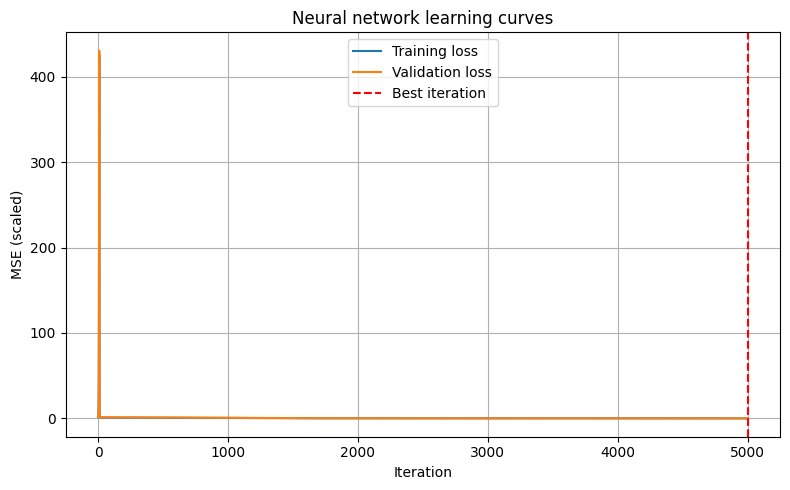

In [89]:
plt.figure(figsize=(8, 5))
plt.plot(best_training_losses, label='Training loss')
plt.plot(best_validation_losses, label='Validation loss')
plt.axvline(best_iteration - 1, color='red', linestyle='--', label='Best iteration')
plt.xlabel('Iteration')
plt.ylabel('MSE (scaled)')
plt.title('Neural network learning curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 5: Evaluate model performance



In [90]:
W1_best, b1_best, W2_best, b2_best = best_parameters

def unscale_y(y_scaled, y_mean, y_std):
    return y_scaled * y_std + y_mean

# Neural network predictions on scaled data
y_train_pred_nn_scaled, _ = forward_regression(x_train_scaled, W1_best, b1_best, W2_best, b2_best)
y_val_pred_nn_scaled, _ = forward_regression(x_val_scaled, W1_best, b1_best, W2_best, b2_best)

# Convert predictions back to the original scale
y_train_pred_nn = unscale_y(y_train_pred_nn_scaled, y_mean, y_std)
y_val_pred_nn = unscale_y(y_val_pred_nn_scaled, y_mean, y_std)

# Compute MSE on the original scale
nn_train_mse = mse(y_train, y_train_pred_nn)
nn_val_mse = mse(y_val, y_val_pred_nn)

print("Best hidden units:", best_hidden_units)
print("Neural Network Training MSE (original scale):", nn_train_mse)
print("Neural Network Validation MSE (original scale):", nn_val_mse)

Best hidden units: 100
Neural Network Training MSE (original scale): 1.1781890611207095
Neural Network Validation MSE (original scale): 1.6432749399489794


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:10: RuntimeWarning: divide by zero encountered in matmul
  y_hat = a1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:10: RuntimeWarning: overflow encountered in matmul
  y_hat = a1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:10: RuntimeWarning: invalid value encountered in matmul
  y_hat = a1 @ W2 + b2


/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/1618343957.py:5: RuntimeWarning: divide by zero encountered in matmul
  y_grid_poly = build_polynomial_features(x_grid, degree=4) @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/1618343957.py:5: RuntimeWarning: overflow encountered in matmul
  y_grid_poly = build_polynomial_features(x_grid, degree=4) @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/1618343957.py:5: RuntimeWarning: invalid value encountered in matmul
  y_grid_poly = build_polynomial_features(x_grid, degree=4) @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:10: RuntimeWarning: divide by zero encountered in matmul
  y_hat = a1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/2831708252.py:10: RuntimeWarning: overflow encountered in matmul
  y_hat = a1 @ W2 + b2
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/i

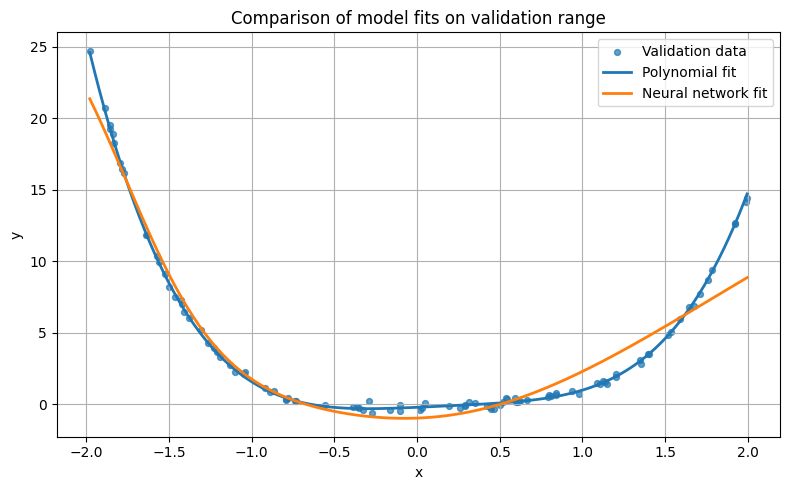

In [91]:
x_grid = np.linspace(min(train_df['x'].min(), val_df['x'].min()),
                     max(train_df['x'].max(), val_df['x'].max()), 400).reshape(-1, 1)

# Polynomial predictions on the original scale
y_grid_poly = build_polynomial_features(x_grid, degree=4) @ poly_coefficients

# Neural network predictions: predict in scaled space, then convert back
x_grid_scaled = (x_grid - x_mean) / x_std
y_grid_nn_scaled, _ = forward_regression(x_grid_scaled, W1_best, b1_best, W2_best, b2_best)
y_grid_nn = unscale_y(y_grid_nn_scaled, y_mean, y_std)

plt.figure(figsize=(8, 5))
plt.scatter(x_val, y_val, s=18, alpha=0.7, label='Validation data')
plt.plot(x_grid, y_grid_poly, linewidth=2, label='Polynomial fit')
plt.plot(x_grid, y_grid_nn, linewidth=2, label='Neural network fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison of model fits on validation range')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 6: Analyse and compare the approaches


In [92]:
# Recompute polynomial predictions on the original scale
poly_train_pred_original = build_polynomial_features(x_train, degree=4) @ poly_coefficients
poly_val_pred_original = build_polynomial_features(x_val, degree=4) @ poly_coefficients

poly_train_mse_original = mse(y_train, poly_train_pred_original)
poly_val_mse_original = mse(y_val, poly_val_pred_original)

# Neural network predictions are already converted back to the original scale in Step 5
nn_train_mse_original = mse(y_train, y_train_pred_nn)
nn_val_mse_original = mse(y_val, y_val_pred_nn)

comparison_df = pd.DataFrame({
    'Model': ['Least Squares Polynomial', 'Neural Network'],
    'Training MSE': [float(poly_train_mse_original), float(nn_train_mse_original)],
    'Validation MSE': [float(poly_val_mse_original), float(nn_val_mse_original)],
    'Generalisation Gap': [
        float(poly_val_mse_original - poly_train_mse_original),
        float(nn_val_mse_original - nn_train_mse_original)
    ]
})

comparison_df

/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/1563670149.py:2: RuntimeWarning: divide by zero encountered in matmul
  poly_train_pred_original = build_polynomial_features(x_train, degree=4) @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/1563670149.py:2: RuntimeWarning: overflow encountered in matmul
  poly_train_pred_original = build_polynomial_features(x_train, degree=4) @ poly_coefficients
/var/folders/6t/fw8ssv5x7w9_42gkvs1ny70c0000gn/T/ipykernel_24694/1563670149.py:2: RuntimeWarning: invalid value encountered in matmul
  poly_train_pred_original = build_polynomial_features(x_train, degree=4) @ poly_coefficients


,Model,Training MSE,Validation MSE,Generalisation Gap
0,Least Squares Polynomial,0.042250,0.030731,-0.011520
1,Neural Network,1.178189,1.643275,0.465086
